In [63]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel , Field
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from typing import TypedDict, List , Dict , Annotated
import operator

In [64]:
load_dotenv()

True

In [65]:
model = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0,
)

In [66]:
class EvaluationSchema(BaseModel):
    feedback:str = Field(description='Detailed Feedback for the essay')
    score: float = Field(ge=0,le=10,description='score out of 10')

In [67]:
structured_model = model.with_structured_output(EvaluationSchema)

In [68]:
blog = """Your Model Made a Call. Can You Defend It?
Understanding Business Intelligence using SHAP values
Moksh
Jun 15, 2026

You trained a model. 99% accuracy. Validation looks clean, AUC is solid, your team is happy. You ship it.

Three weeks later, it flags a high-profile account for spam. The person complains. Your manager walks over and asks

    “Why did the model make this call?”

And you realise you don't actually have a good answer.

You know the model is good.

You know it works.

But you cannot explain a single specific prediction. Not to your manager, not to the user, not to yourself.
Let’s take a real example

You’re an ML engineer at X (formerly Twitter).

Your job? Flag accounts that are spammy, harmful, or promoting genuinely negative content. You’ve trained a model, it’s performing well, and in a recent run it flagged 500+ accounts across a sample.

Notifications go out. Accounts get suspended.

Now your team lead walks in and asks “What exactly is the model picking up on? What features are driving these flags?”

That’s a fair question, and honestly, a pretty easy one to answer. You just pull up your feature importance scores.

If you’re using a tree-based model like XGBoost or Random Forest, this is built in, so we can use feature importance to understand the contribution of features for the entire data.
Feature importance tells us how decisions were taken for an entire sample

Feature importance is great for this. It tells you the global picture

    how the model behaves overall across all 500+ predictions.

But then something else happens.

One of those 500 flagged accounts belongs to a well-known influencer. Millions of followers. Verified. And they are not happy.

They’ve raised a formal complaint. Their legal team is involved. And now someone in your company needs to explain, not just “the model flagged you,” but why.

    What specific factors led to this specific account getting suspended?

This is where feature importance breaks down completely.

Feature importance tells you which features matter on average, across the whole dataset. It does not tell you what happened for account #247 out of your 500.

The influencer doesn’t care about averages. They want to know what about their account triggered this.

That’s a completely different question and that’s exactly what SHAP Values are built to answer.
SHAP Values

To understand the contribution of each feature for a single prediction we use SHAP Values

    so in our given example we will just plot the shap values for the particular prediction and can get a graph like this

For the influencer’s account, we generated the following SHAP explanation.

    Each bar represents a feature that influenced the model’s decision.

    Features shown in red pushed the prediction towards the “spam/harmful account” class, while features shown in blue pushed it away from that class.

    The length of each bar indicates the magnitude of that feature’s contribution.

In this example, we can observe that:

    A high number of reports from other users strongly pushed the prediction towards the spam category.

    An unusually high posting frequency also increased the probability of the account being flagged.

    Recent account verification status reduced the spam probability and acted as a counter-argument against termination.

    A long account age also contributed positively towards legitimacy.

    What makes SHAP powerful is that it doesn’t simply tell us which features are important overall.

    Instead, it explains exactly why this particular account received this particular prediction.

Feature Importance vs SHAP Values

Feature Importance answers:

    Which features matter the most across the entire dataset?

SHAP Values answer:

    Why did the model make this decision for this specific prediction?

As machine learning systems become increasingly involved in moderation, lending, healthcare, hiring, and recommendation systems, being able to justify individual predictions is often just as important as achieving high accuracy.

SHAP Values provides Interpretability to these black boxes (ML Models) even black-box ones like gradient boosting or neural networks interpretable at the level of a single prediction.

A model that is 99% accurate but cannot explain its decisions may be difficult to trust in production.
Let’s have a hands on practice around SHAP values and utilize them to understand the contribution of each feature for single prediction

we are going to use a Loan Approval Dataset from kaggle

Link to dataset- Loan-approval-prediction-dataset

Link to Google Colab notebook - HandsOnNotebook
Step 1: Import Libraries

import pandas as pd
import numpy as np
import xgboost as xgb
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

Step 2: Load the Dataset

Our dataset contains information about loan applicants.

df = pd.read_csv("loan_approval_dataset.csv")
df.head()

Step 3: Encode Categorical Features

Machine Learning models cannot directly understand text values.

le_education = LabelEncoder()
le_self_employed = LabelEncoder()
le_target = LabelEncoder()

df["education"] = le_education.fit_transform(df["education"])
df["self_employed"] = le_self_employed.fit_transform(df["self_employed"])

df["loan_status"] = le_target.fit_transform(df["loan_status"])

Step 4: Split Features and Target

X = df.drop(["loan_id", "loan_status"], axis=1)

y = df["loan_status"]

Step 5: Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Step 6: Train an XGBoost Model

Tree-based models work extremely well with SHAP.

model = xgb.XGBClassifier(
    max_depth=4,
    n_estimators=100,
    learning_rate=0.1,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

Step 7: Generate SHAP Values

we create an explainer object and pass all values of test in explainer object

explainer = shap.Explainer(model)

shap_values = explainer(X_test)

At this point, SHAP has calculated how much each feature contributes to every prediction.
Step 8: Global Feature Importance

Let’s first understand which features matter most across the entire dataset.

shap.plots.bar(shap_values)

This gives us a dataset-level view.

For example, we might observe that:

    CIBIL Score has the largest influence

    Income plays a major role

    Asset values affect approval decisions

This is similar to traditional feature importance.
Step 9: Individual Prediction Explanation

Now let’s inspect a single applicant.

shap.plots.waterfall(shap_values[0])

This is where SHAP becomes truly useful.

Instead of explaining the model globally, it explains a single decision.

The waterfall chart tells us:

    Which features pushed the prediction toward approval

    Which features pushed it toward rejection

    The magnitude of each contribution

For example:

    High CIBIL score may strongly increase approval probability

    High annual income may further support approval

    Large loan amount may decrease approval probability

Together these factors produce the final prediction.
Step 10: Understanding Feature Behavior Across All Applicants

shap.plots.beeswarm(shap_values)

The beeswarm plot combines thousands of local explanations into one visualization.

It answers questions such as:

    Does a higher CIBIL score generally increase approval chances?

    Does income consistently help?

    Which features have the largest variation in impact?

This plot is often the most informative SHAP visualization in real-world projects.

Traditional evaluation metrics such as Accuracy, Precision, Recall, or AUC can tell us how well a model performs, but they cannot explain individual decisions.

Feature Importance helps us understand what matters to the model overall.

SHAP takes it a step further by explaining how those features contributed to a specific prediction.

Whether you’re building loan approval systems, fraud detection pipelines, recommendation engines, healthcare models, or content moderation systems, explainability is no longer a luxury. It’s a requirement.

Because in production, the most important question is often not:

“How accurate is the model?”

It’s:

“Can we explain why it made this decision?”

And that’s exactly what SHAP helps us do.
Back to our real problem!

So, back to that influencer.

With SHAP, you’re not stuck saying “the model flagged you, trust us.” You pull up the waterfall plot and actually show them: yes, your posting frequency spiked, yes, you got a sudden wave of reports, and your account age and verification status did work in your favor, just not enough to outweigh the rest.

Your manager doesn’t have to take your word for it anymore. Neither does the influencer’s legal team. You can just point at the bars.

That’s the real shift SHAP brings to the table. Not “the model is 99% accurate, trust the number,” but “here’s exactly what happened for this one account, and here’s why.”

Going further

Now, SHAP works great when you already have labels, spam or not spam, approved or rejected. But what happens when you don’t?

What if you’re trying to catch the accounts that don’t look like anything in your training data at all? No history of being flagged, no labeled examples to learn from, just... weird.

That’s a completely different problem, anomaly detection, and it’s where Isolation Forest comes in. We’ll get into that next.
"""

In [69]:
prompt=f"evaluate the langauge quality of the following technical blog {blog}"

In [70]:
response = structured_model.invoke(prompt)

In [71]:
response

EvaluationSchema(feedback="The blog post is engaging and tells a relatable story that draws the reader in, which is a strong point for a technical audience. The overall structure follows a logical flow: it starts with a motivating scenario, introduces the limitation of global feature importance, presents SHAP as the solution, walks through a concrete hands‑on example, and then circles back to the original problem. This narrative arc helps maintain interest.\n\n**Clarity & Readability**\n- The language is mostly clear, but there are several places where sentence construction is awkward or overly informal for a technical blog (e.g., “You know the model is good. You know it works.”). Tightening these sentences would improve professionalism.\n- Some headings are missing proper capitalization (e.g., “Let’s have a hands on practice around SHAP values”). Consistent title‑case would aid scanning.\n- The transition from the influencer story to the loan‑approval example feels abrupt. Adding a br

In [72]:
class UPSCState(TypedDict):
    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str

    individual_scores: Annotated[List[int],operator.add]
    avg_score: float

In [73]:
def evaluate_language(state: UPSCState):

    prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}'
    output = structured_model.invoke(prompt)

    return {'language_feedback': output.feedback, 'individual_scores': [output.score]}

def evaluate_analysis(state: UPSCState):

    prompt = f'Evaluate the depth of analysis of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}'
    output = structured_model.invoke(prompt)

    return {'analysis_feedback': output.feedback, 'individual_scores': [output.score]}

def evaluate_thought(state: UPSCState):

    prompt = f'Evaluate the clarity of thought of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}'
    output = structured_model.invoke(prompt)

    return {'clarity_feedback': output.feedback, 'individual_scores': [output.score]}

def final_evaluation(state: UPSCState):

    # summary feedback
    prompt = f'Based on the following feedbacks create a summarized feedback \n language feedback - {state["language_feedback"]} \n depth of analysis feedback - {state["analysis_feedback"]} \n clarity of thought feedback - {state["clarity_feedback"]}'
    overall_feedback = model.invoke(prompt).content

    # avg calculate
    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])

    return {'overall_feedback': overall_feedback, 'avg_score': avg_score}


In [74]:


graph = StateGraph(UPSCState)

graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_thought', evaluate_thought)
graph.add_node('final_evaluation', final_evaluation)

# edges
graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_thought')

graph.add_edge('evaluate_language', 'final_evaluation')
graph.add_edge('evaluate_analysis', 'final_evaluation')
graph.add_edge('evaluate_thought', 'final_evaluation')

graph.add_edge('final_evaluation', END)

workflow = graph.compile()



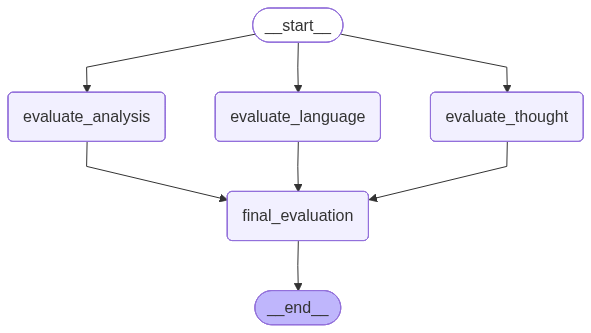

In [75]:
workflow

In [76]:
workflow.invoke({
    'essay':blog
})

{'essay': 'Your Model Made a Call. Can You Defend It?\nUnderstanding Business Intelligence using SHAP values\nMoksh\nJun 15, 2026\n\nYou trained a model. 99% accuracy. Validation looks clean, AUC is solid, your team is happy. You ship it.\n\nThree weeks later, it flags a high-profile account for spam. The person complains. Your manager walks over and asks\n\n    “Why did the model make this call?”\n\nAnd you realise you don\'t actually have a good answer.\n\nYou know the model is good.\n\nYou know it works.\n\nBut you cannot explain a single specific prediction. Not to your manager, not to the user, not to yourself.\nLet’s take a real example\n\nYou’re an ML engineer at X (formerly Twitter).\n\nYour job? Flag accounts that are spammy, harmful, or promoting genuinely negative content. You’ve trained a model, it’s performing well, and in a recent run it flagged 500+ accounts across a sample.\n\nNotifications go out. Accounts get suspended.\n\nNow your team lead walks in and asks “What ex

In [77]:
blog2="""
Data Version Control
From version controlling code to version controlling your entire ML pipeline.
Moksh
May 27, 2026
Git and why it fails in ML pipelines

Well, most of us are aware about Git and how it can be used as a version control system for our entire codebase.

however, its just worth to ensure that we are on the same page
every time we made a commit git stores that particular version of code to which we can rollback if required.

With each commit git generates a sha-id which can be essentially used to roll back by running the command

git checkout <sha-id-of-your-commit>

Pretty powerful right?

Well, For most of the part yes!
But if we talk about Machine Learning Systems , where we have data files whose size is generally larger than what essentially git can track . it becomes impossible for us to track those files using git

    Lets have a look at the root directory of very basic ML system 

credit-card-fraud-detection-system/
├── data/
│   ├── raw/fraud_dataset.csv          # 150MB
│   └── processed/train_scaled.npy     # 200MB
├── models/
│   └── xgboost_v3_recall_tuned.pkl    # 400MB
├── notebooks/
│   └── eda.ipynb
└── src/
    └── train.py

Now try running git add data/ on that 150MB CSV.

    GitHub will reject files over 100MB.

    Even if it didn’t do you want to store binary blobs in your Git history?

    Every commit would balloon in size.

    Cloning the repo would take minutes.

    Diffs would be meaningless (you can’t diff a .pkl file)

The core problem:

    Git is built for code

ML projects are code + data + models + metrics , and these are interdependent on each other , a change or update in data would result in different metrics over time.

also, while training models our interest lies in experimenting with different set of parameters, models , and data splits to get the best possible model for a given problem.

Git is not built for tracking data , models and providing a modular way to track our experiments
Lets take a real scenario:

You are a data scientist intern working at a fintech startup building a credit card fraud detection system. After weeks of experimentation, your team lead walks up and asks:

    "Hey, last Tuesday you ran that experiment where you used the 80-20 split with XGBoost and got a recall of 0.91, can you show me those exact results again? Also what were the feature importances? And what was the precision at that threshold?"

You open your laptop.

Your notebook is called ‘‘final_v3_ACTUAL_final_USE_THIS.ipynb’’

You scroll up. Then down. Then up again.

    The cell outputs are gone, you restarted the kernel yesterday.

    The model file got overwritten when you retrained.

    The dataset got updated when your colleague pushed new labeled samples.

    The threshold you used? You think it was 0.42. Or maybe 0.38. You tried both.

You remember the recall was good but you cannot reproduce it because:

    The data has changed : new samples were added, you have no record of what the dataset looked like last Tuesday

    The model file is gone : overwritten by the latest training run

    The parameters are buried somewhere in a cell you may have edited three times since

    The metrics were only in the cell output : which you cleared

    The preprocessing steps : did you use StandardScaler or MinMaxScaler that run? You switched between them twice

So you do the only thing you can do.

You retrain. From scratch. Hoping you remember every decision you made last Tuesday.

    Your team lead is still waiting

This is exactly the problem DVC solves.
Data Version Control

DVC (Data Version Control) is an open source version control system specifically built for machine learning projects.

It works alongside Git , not as a replacement.

Git continues to track code. DVC tracks data, models, and metrics. Together they give you complete reproducibility of the entire ML pipeline.
But how does dvc solves this problem?

    dvc generates a basic pointer that points towards the specific version your data either remotely or locally , git just tracks the pointer and not the entire data or model 

for example in this case our interim folder is begin tracked by dvc with the help of a md5 hash id, dvc.lock is tracked by git itself , giving us the version of data for a given version of code.
Getting Started with dvc

Let’s get back to our spam detection system, but this time take a real example of an email spam detection system, and to your surprise we have a github repo waiting for us to setup and understand dvc

    Clone the github repository 

git clone https://github.com/moksh-m9u/dvc-blog-tutorial.git
cd dvc-blog-tutorial

    Install the requirements

pip install -r requirements.txt

Understanding the repository structure, (optional step just in case you wish to explore more)here in order to run the notebooks in experimentation, we must first install the data set from kaggle hub , email spam detecion dataset and place it in experiments folder

DVC-BLOG-TUTORIAL/
├── experiments/
│   ├── mynotebook.ipynb
│   └── notebook.ipynb
├── src/
│   ├── data_ingestion.py
│   ├── data_preprocessing.py
│   ├── feature_engineering.py
│   ├── model_building.py
│   └── model_evaluation.py
├── .gitignore
├── dvc.yaml
├── params.yaml
├── README.md
└── requirements.txt

    In this project you would notice that , the experiments are separated from actual modular pipelines, and that’s the standard one follows, this provides you modularity and allows you to monitor your pipeline over longer runs or in production

    params.yaml contains different sets of parameters your modular pipeline uses, think of it like a config file we can directly make any sort of changes in this file to implement it in our pipeline.

data_ingestion:
  test_size: 0.2
feature_engineering:
  max_features: 400
model_building:
  n_estimators: 900
  random_state: 2

    Initializing dvc

        as simple as initializing a git repo!

dvc init 

    Running the entire pipeline (reproducing)

dvc repro

now this runs your entire pipeline in just one command!
else you would have to run this modules iteratively or maybe using a python script but the main power of dvc lies in its functionality to provide tracking over you data

Running this pipeline would create this folders in your directory, the thing to notice here is that these files will not be tracked by git,

but git tracks .dvc file which essentially contains information about version of our data and models

    Tracking a untracked file (data) using dvc :

dvc add experiments/dataset.csv    #you can only perform this if you downloaded the dataset from kagglehub

link to dataset - https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

you can download and add this data set into your experiments folder to follow along step 4

    now dvc will keep a track of this file too!

    Note that files already tracked by git can not be tracked by dvc

    Tracking and committing this change 

now , we need to track and push this one iteration so that it can be fetched if required in future

dvc repro
git add .
git commit -m "Experiment 1: max_features=400, n_estimators=900"
dvc push   

or we can simply run

dvc exp run

now this is a more cleaner way , in which we don’t have multiple commits for each experiment and dvc track everything for you
Real power of dvc

the real power of dvc lies in doing multiple experiments and choosing the best one out of them

    go to params.yaml and make some arbitrary changes to the numeric values of parameters 

data_ingestion:
  test_size: 0.3
feature_engineering:
  max_features: 350
model_building:
  n_estimators: 750
  random_state: 42

now we will reproduce a pipeline with these new set of parameters

dvc exp run 

now just notice that your metrics in your reports folder will be changed.
But how to track all these?

just simply run or you could install dvc extension in your IDE to visualize it better

dvc exp show

Now every change you make , to the parameters of your model , you would simply run dvc exp run and that would just keep a track and do the heavy lifting for you!

Now a better way to visualize this is with help of dvc extension

    Install this dvc extension you IDE

    Locate dvc path and you are all set to get a better user experience of your experiments!

and you can rollback to any version of your parameters , data and model based on the requirement of the given problem ,

    and btw you can answer your senior in less than 15 seconds by simply running

dvc exp apply b35f590

and you are on your previous model!
Each experiment has this unique id through which we can rollback to any previous version , logically to model which has more accuracy , precision or recall depending on our use case and dvc keeps track of all these changes locally
About me!

well, this is my first blog, and i hope this added a bit value or maybe……..

a lil bit about me:

    I’m Moksh.

    Digital wanderer stuck between Strava, Kaggle, and Claude. Half my tabs are ML research papers. The other half are Fight Club, Alice in Borderland, and well…… what not

    I'm deep in the trenches of learning the craft.

    linkedin - https://www.linkedin.com/in/mokshhh/

    X- x.com/moksh1326

    kaggle-https://www.kaggle.com/moksh067

Thanks for reading my Substack! 
"""

In [79]:
workflow.invoke({
    'essay':blog2
})

{'essay': '\nData Version Control\nFrom version controlling code to version controlling your entire ML pipeline.\nMoksh\nMay 27, 2026\nGit and why it fails in ML pipelines\n\nWell, most of us are aware about Git and how it can be used as a version control system for our entire codebase.\n\nhowever, its just worth to ensure that we are on the same page\nevery time we made a commit git stores that particular version of code to which we can rollback if required.\n\nWith each commit git generates a sha-id which can be essentially used to roll back by running the command\n\ngit checkout <sha-id-of-your-commit>\n\nPretty powerful right?\n\nWell, For most of the part yes!\nBut if we talk about Machine Learning Systems , where we have data files whose size is generally larger than what essentially git can track . it becomes impossible for us to track those files using git\n\n    Lets have a look at the root directory of very basic ML system \n\ncredit-card-fraud-detection-system/\n├── data/\n│